In [446]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Task 1: Data Understanding & Exploration

In [447]:
data = pd.read_csv("/content/G2.csv")
#dataset is stored.
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [448]:
data.shape
#This dataset has 1351 rows and 10 columns.

(1351, 10)

In [449]:
data.describe()
#Finding various info about dataset like count, mean, std, etc

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [450]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB


In [451]:
numeric_column = data.select_dtypes(include=['float64', 'int64']).columns
categorical_column = data.select_dtypes(include=['object']).columns

print(f"The Numerical Columns are: {numeric_column}")
print(f"The Categorical Columns are: {categorical_column}")

The Numerical Columns are: Index(['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack',
       'defense'],
      dtype='object')
The Categorical Columns are: Index(['name', 'type_1', 'type_2'], dtype='object')


In [452]:
data.isna().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


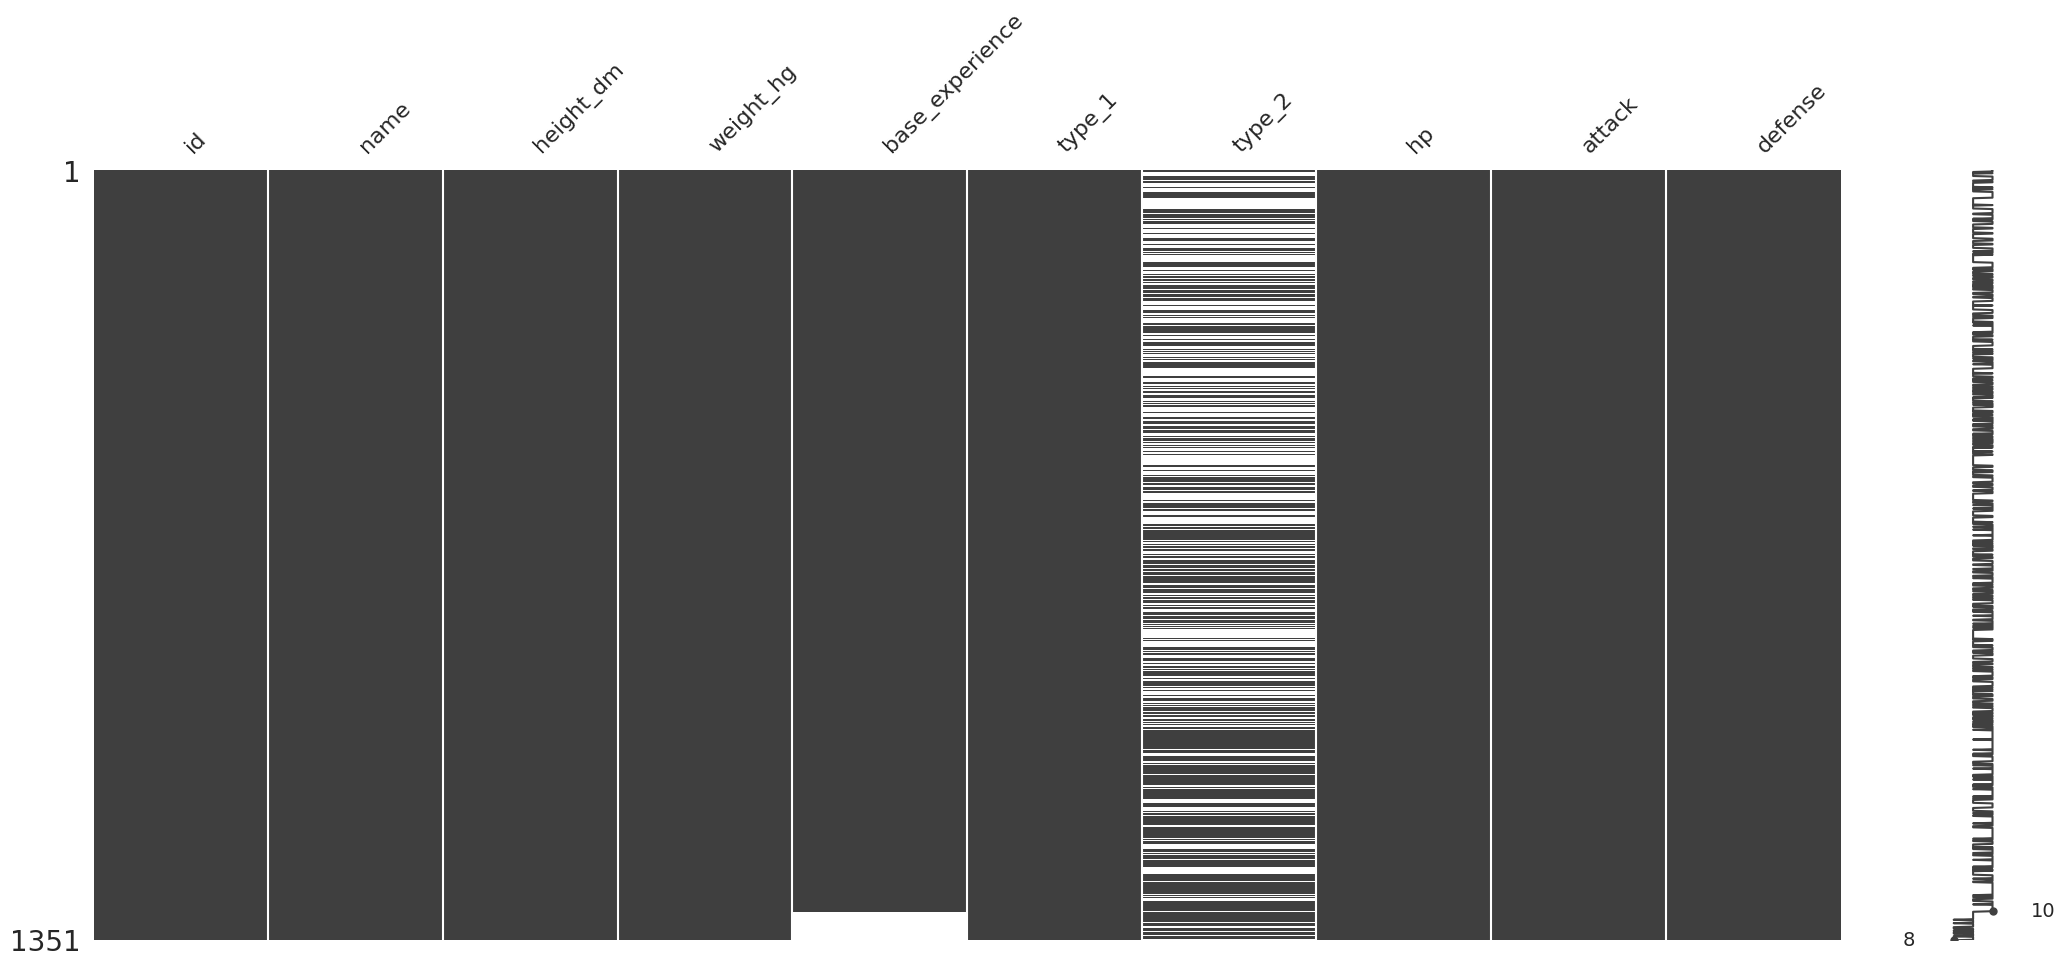

In [453]:
import missingno as msn
matrix = msn.matrix(data)

In [454]:
#There is no duplicates in the data.
data.duplicated().sum()

np.int64(0)

In [455]:
df = pd.read_csv("/content/G2.csv")

# Basic dataset information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())

# -----------------------------
# 2. General summary statistics
# -----------------------------
print("\nGeneral summary statistics:")
print(df.describe(include="all").T)

# Numeric summary statistics
numeric_columns = df.select_dtypes(include="number").columns

print("\nNumeric summary statistics:")
print(df[numeric_columns].describe().T)

# Categorical summary statistics
categorical_columns = ["type_1", "type_2"]

print("\nCategorical summary statistics:")
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].describe())


# Exclude identifiers and target/categorical columns
numeric_features = [
    "height_dm",
    "weight_hg",
    "base_experience",
    "hp",
    "attack",
    "defense"
]


Dataset shape: (1351, 10)

Column names:
['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1', 'type_2', 'hp', 'attack', 'defense']

First five rows:
   id        name  height_dm  weight_hg  base_experience type_1  type_2  hp  \
0   1   bulbasaur          7         69             64.0  grass  poison  45   
1   2     ivysaur         10        130            142.0  grass  poison  60   
2   3    venusaur         20       1000            236.0  grass  poison  80   
3   4  charmander          6         85             62.0   fire     NaN  39   
4   5  charmeleon         11        190            142.0   fire     NaN  58   

   attack  defense  
0      49       49  
1      62       63  
2      82       83  
3      52       43  
4      64       58  

General summary statistics:
                  count unique                   top freq        mean  \
id               1351.0    NaN                   NaN  NaN  2841.69208   
name               1351   1351  meowstic-female-mega    1 

In [456]:

# Summary of variation
variation = pd.DataFrame({
    "variance": df[numeric_features].var(),
    "std_deviation": df[numeric_features].std(),
    "min": df[numeric_features].min(),
    "max": df[numeric_features].max(),
    "range": df[numeric_features].max() - df[numeric_features].min(),
    "missing_values": df[numeric_features].isna().sum()
})

# Coefficient of variation:
# CV = standard deviation / mean
variation["coefficient_of_variation"] = (
    variation["std_deviation"] / df[numeric_features].mean().abs()
)

# Sort by raw variance
print("Sorted by raw variance:")
print(variation.sort_values("variance", ascending=False))

# Sort by relative variation
print("\nSorted by coefficient of variation:")
print(
    variation.sort_values(
        "coefficient_of_variation",
        ascending=False
    )
)

Sorted by raw variance:
                     variance  std_deviation   min      max    range  \
weight_hg        3.814661e+06    1953.115812   0.0  10000.0  10000.0   
base_experience  6.811623e+03      82.532554  36.0    608.0    572.0   
height_dm        2.834334e+03      53.238467   1.0   1000.0    999.0   
attack           1.046646e+03      32.351906   5.0    190.0    185.0   
defense          9.432824e+02      30.712902   5.0    250.0    245.0   
hp               7.197163e+02      26.827529   1.0    255.0    254.0   

                 missing_values  coefficient_of_variation  
weight_hg                     0                  1.970734  
base_experience              49                  0.509637  
height_dm                     0                  2.604192  
attack                        0                  0.390922  
defense                       0                  0.403089  
hp                            0                  0.374302  

Sorted by coefficient of variation:
              

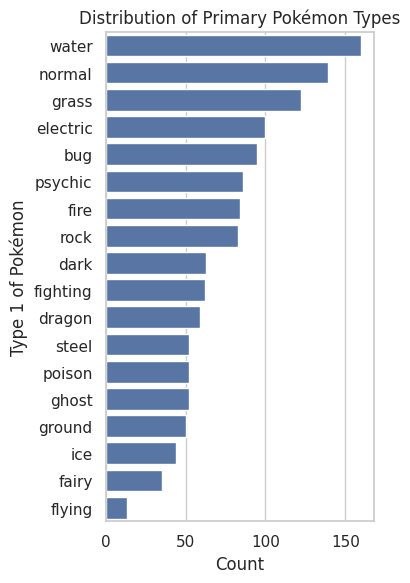

In [457]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 6))

sns.countplot(
    data=data,
    y="type_1",
    order=data["type_1"].value_counts().index
)

plt.xlabel("Count")
plt.ylabel("Type 1 of Pokémon")
plt.title("Distribution of Primary Pokémon Types")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Count of type 2 of Pokemon')

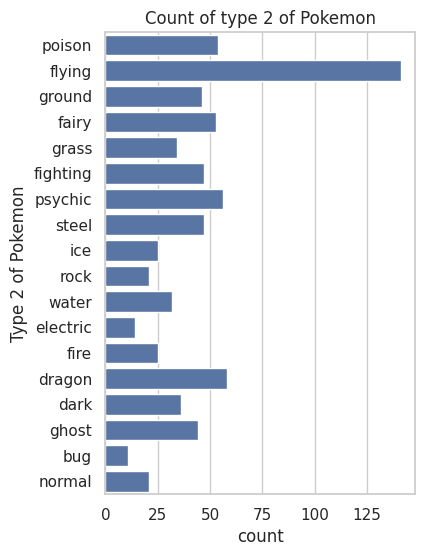

In [458]:
plt.figure(figsize=(4,6))
sns.countplot(data=data, y='type_2')
plt.xlabel('count')
plt.ylabel('Type 2 of Pokemon')
plt.title('Count of type 2 of Pokemon')

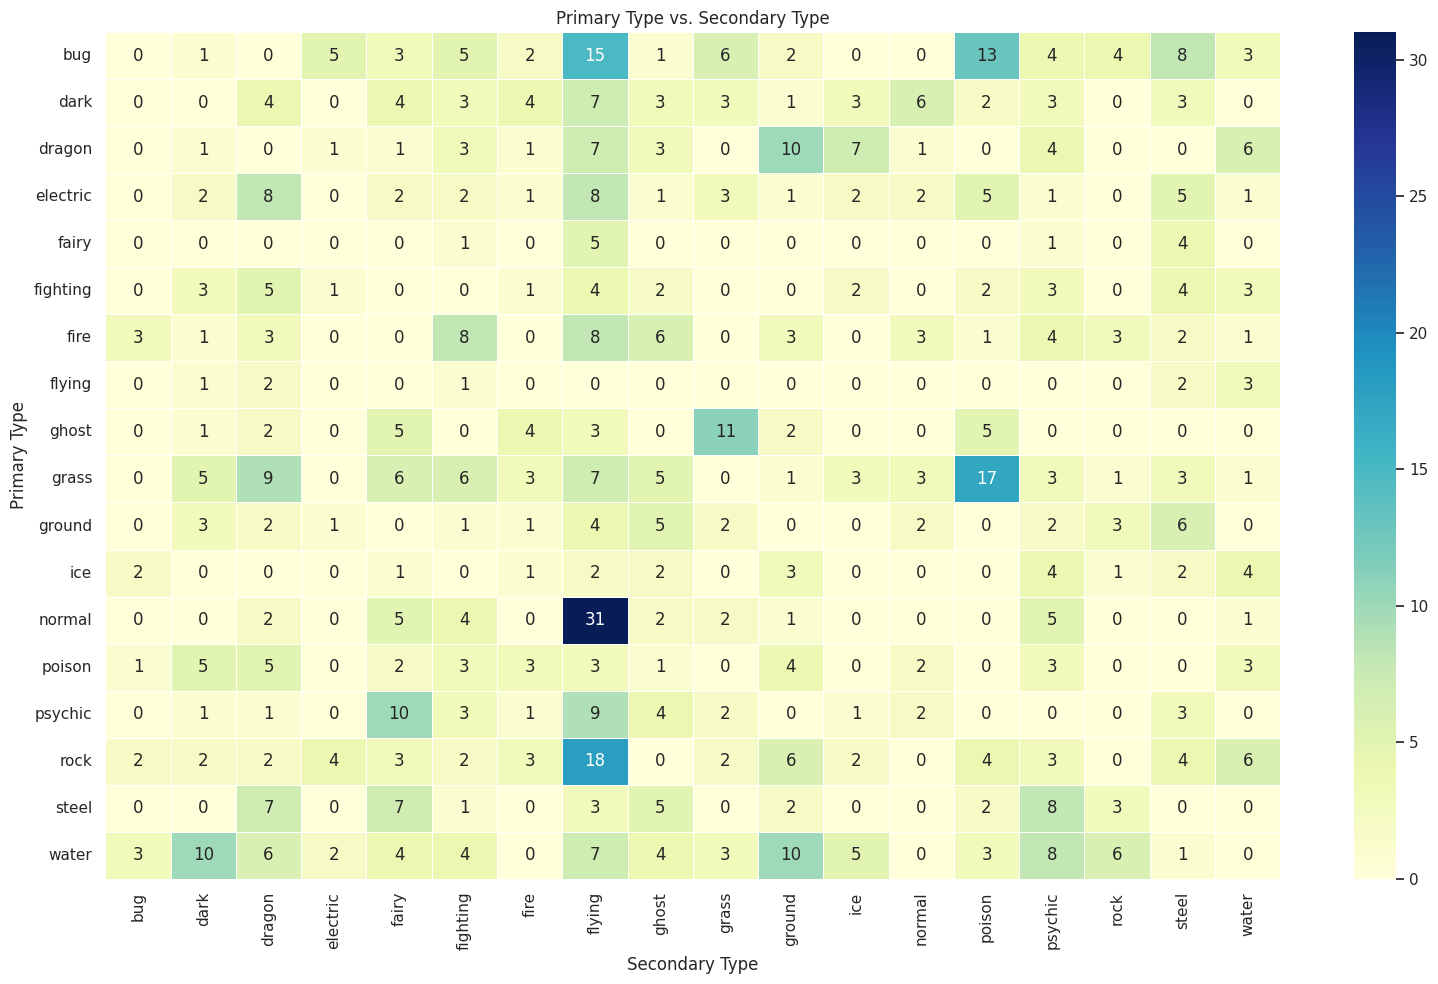

In [459]:
# -----------------------------
# 10. Primary type vs. secondary type heatmap
# -----------------------------
type_relationship = pd.crosstab(
    df["type_1"],
    df["type_2"]
)

plt.figure(figsize=(16, 10))

sns.heatmap(
    type_relationship,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Primary Type vs. Secondary Type")
plt.xlabel("Secondary Type")
plt.ylabel("Primary Type")
plt.tight_layout()
plt.show()


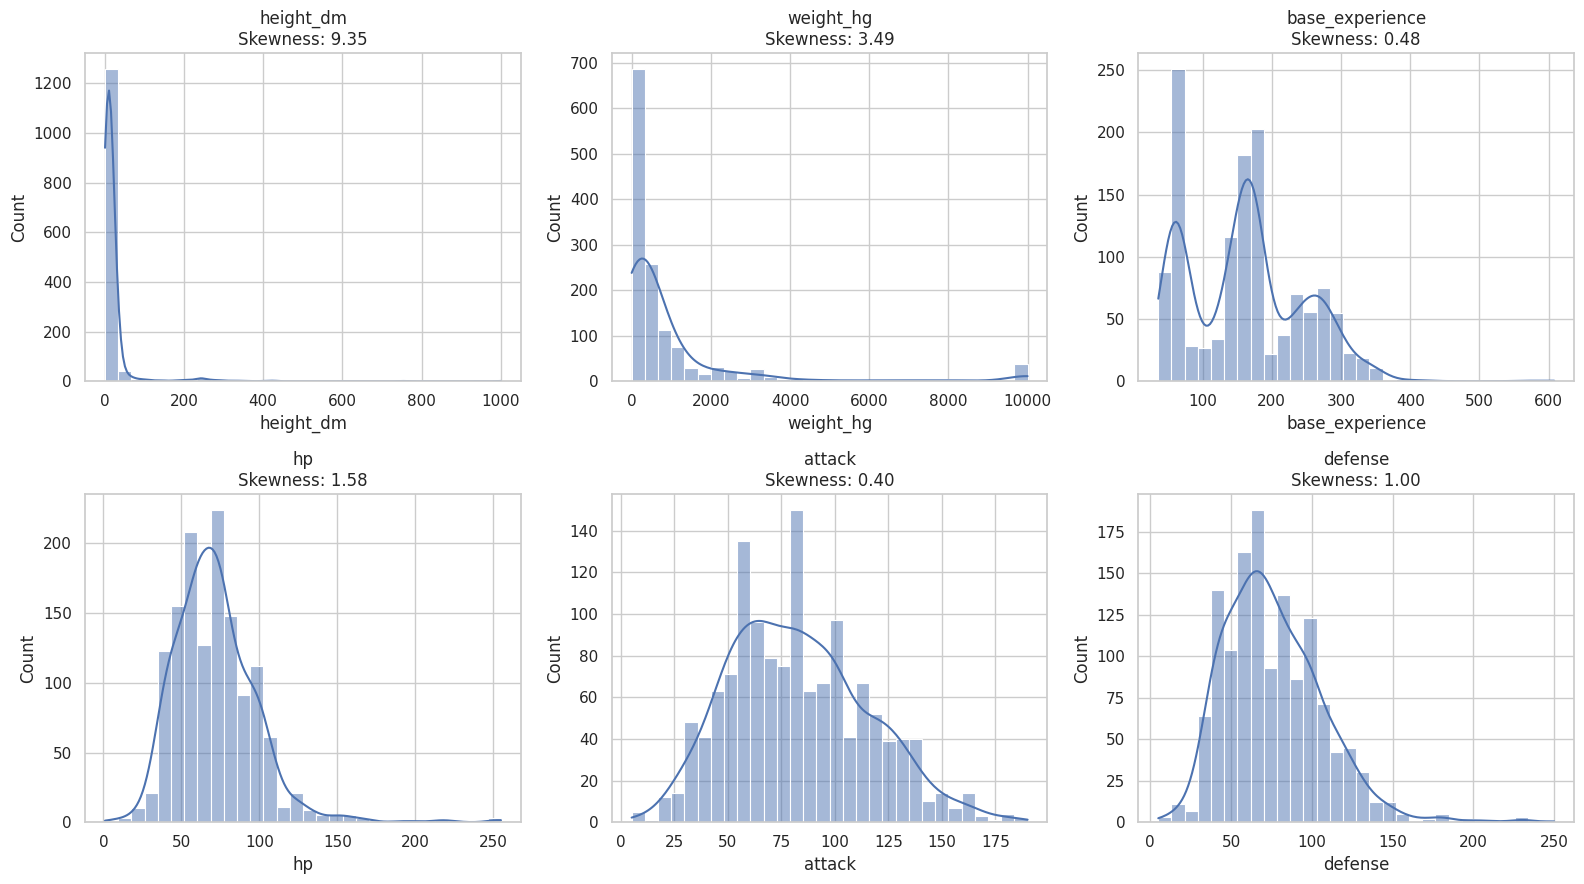

In [460]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, column in zip(axes, numeric_features):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30,
        ax=ax
    )
    ax.set_title(
        f"{column}\nSkewness: {df[column].skew():.2f}"
    )

plt.tight_layout()
plt.show()

1. In Type 1, Water is the most appeared while most pokemons doesnot have a secondary type.

2. Height_dm is the numerical feature with most variance.

3. In this dataset,
This dataset has 1351 rows and 10 columns. The columns are
'id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1', 'type_2', 'hp', 'attack', 'defense'. There are several missing values in type 2 and base experience. height_dm and weight_hg is highly skewed.

#Data Preprocessing

In [461]:
#Log Transformation
df["height_dm_log"] = np.log1p(df["height_dm"])
df["weight_hg_log"] = np.log1p(df["weight_hg"])
df["hp_log"] = np.log1p(df["hp"])

In [462]:
print("Original skewness of height:", df["height_dm"].skew())
print("Log-transformed skewness of height:", df["height_dm_log"].skew())
print()
print("Original skewness of weight:", df["weight_hg"].skew())
print("Log-transformed skewness of weight:", df["weight_hg_log"].skew())
print()
print("Original skewness of hp:", df["hp"].skew())
print("Log-transformed skewness of hp:", df["hp_log"].skew())
print()

Original skewness of height: 9.34809300049638
Log-transformed skewness of height: 1.2810753374562094

Original skewness of weight: 3.492945753251682
Log-transformed skewness of weight: -0.2938420169949568

Original skewness of hp: 1.5838197543805344
Log-transformed skewness of hp: -0.9293920980921292



In [463]:
#Since some pokemon does only have a single type, filling the missing value with none.
data["type_2"] = data["type_2"].fillna("none")
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,none,39,52,43
4,5,charmeleon,11,190,142.0,fire,none,58,64,58


In [464]:
#Replacing base_experience Null value with median.
data['base_experience'] = data['base_experience'].fillna(data['base_experience'].median())
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,none,39,52,43
4,5,charmeleon,11,190,142.0,fire,none,58,64,58


In [465]:
data['type_2'].value_counts()

,count
type_2,
none,586
flying,141
dragon,58
psychic,56
poison,54
fairy,53
steel,47
fighting,47
ground,46


In [466]:
data['type_2'].value_counts()

,count
type_2,
none,586
flying,141
dragon,58
psychic,56
poison,54
fairy,53
steel,47
fighting,47
ground,46


In [467]:
data['type_2'].nunique()

19

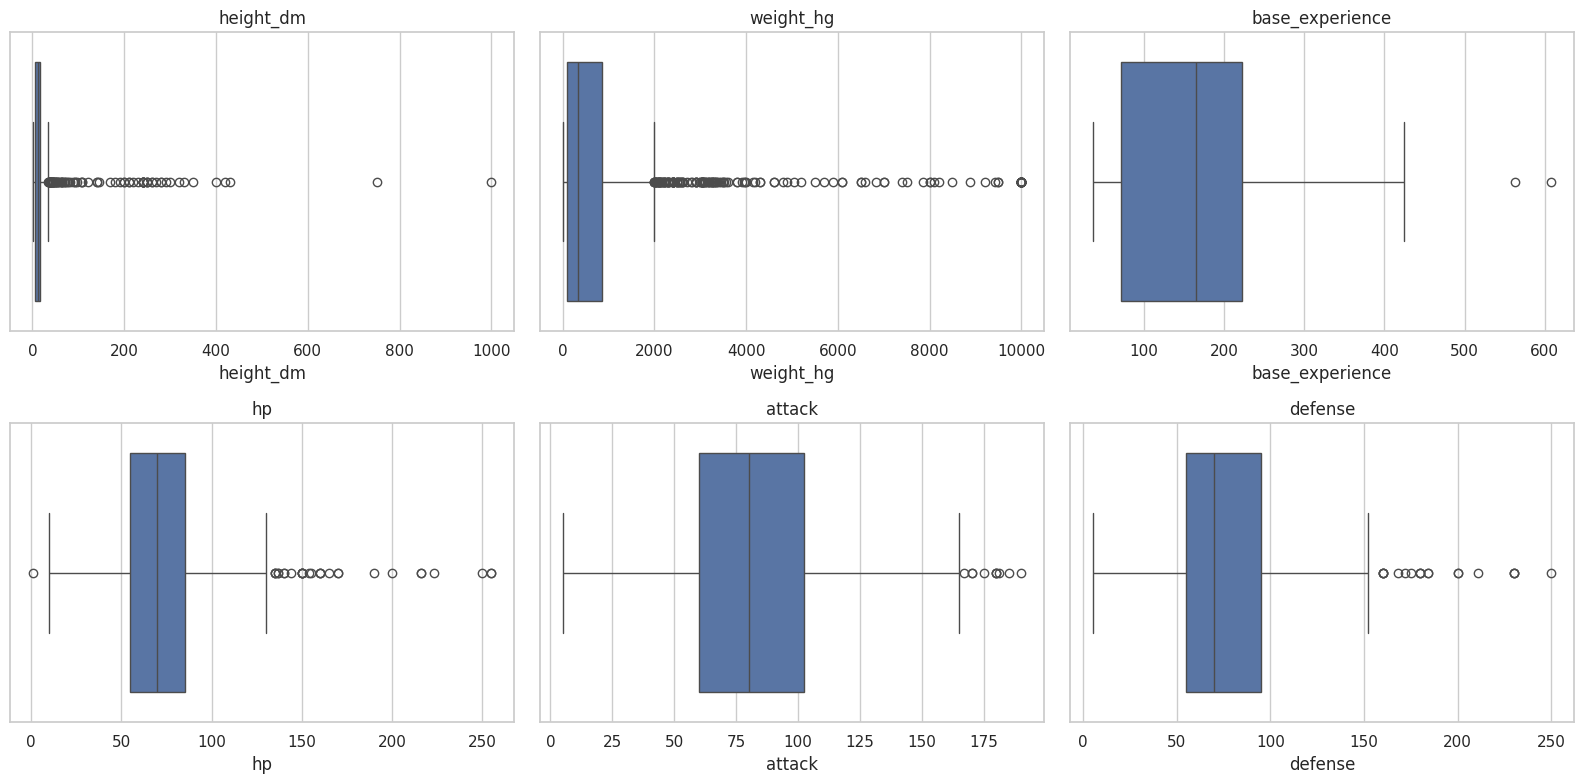

In [468]:
#Checking outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_features):
    sns.boxplot(data=df, x=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [469]:
#Handling Outliers
numerical_cols = ['height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']
for col in numerical_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Cap values at the lower and upper bounds
  data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

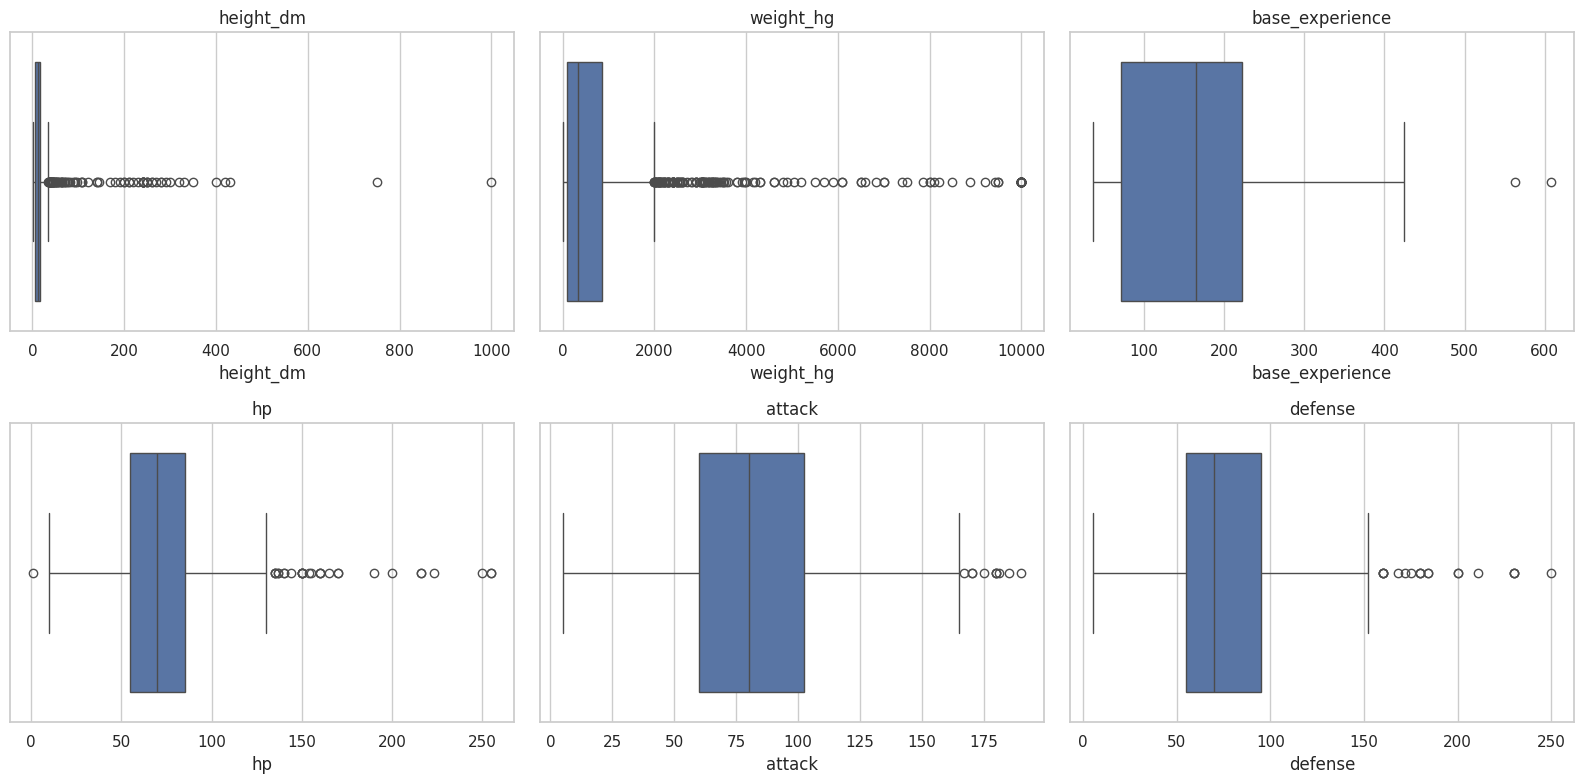

In [470]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_features):
    sns.boxplot(data=df, x=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [471]:
#One-Hot Encoding
data = pd.get_dummies(data=data,columns=['type_2'])

In [472]:
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,hp,attack,defense,type_2_bug,...,type_2_grass,type_2_ground,type_2_ice,type_2_none,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
0,1,bulbasaur,7.0,69,64.0,grass,45,49.0,49,False,...,False,False,False,False,False,True,False,False,False,False
1,2,ivysaur,10.0,130,142.0,grass,60,62.0,63,False,...,False,False,False,False,False,True,False,False,False,False
2,3,venusaur,20.0,1000,236.0,grass,80,82.0,83,False,...,False,False,False,False,False,True,False,False,False,False
3,4,charmander,6.0,85,62.0,fire,39,52.0,43,False,...,False,False,False,True,False,False,False,False,False,False
4,5,charmeleon,11.0,190,142.0,fire,58,64.0,58,False,...,False,False,False,True,False,False,False,False,False,False


In [473]:
data.columns

Index(['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1',
       'hp', 'attack', 'defense', 'type_2_bug', 'type_2_dark', 'type_2_dragon',
       'type_2_electric', 'type_2_fairy', 'type_2_fighting', 'type_2_fire',
       'type_2_flying', 'type_2_ghost', 'type_2_grass', 'type_2_ground',
       'type_2_ice', 'type_2_none', 'type_2_normal', 'type_2_poison',
       'type_2_psychic', 'type_2_rock', 'type_2_steel', 'type_2_water'],
      dtype='object')

In [474]:
#Label Encoding True or False
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_cols = ['type_2_bug', 'type_2_dark', 'type_2_dragon',
       'type_2_electric', 'type_2_fairy', 'type_2_fighting', 'type_2_fire',
       'type_2_flying', 'type_2_ghost', 'type_2_grass', 'type_2_ground',
       'type_2_ice', 'type_2_none', 'type_2_normal', 'type_2_poison',
       'type_2_psychic', 'type_2_rock', 'type_2_steel', 'type_2_water']
for col in label_cols:
  data[col] = le.fit_transform(data[col])
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,hp,attack,defense,type_2_bug,...,type_2_grass,type_2_ground,type_2_ice,type_2_none,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
0,1,bulbasaur,7.0,69,64.0,grass,45,49.0,49,0,...,0,0,0,0,0,1,0,0,0,0
1,2,ivysaur,10.0,130,142.0,grass,60,62.0,63,0,...,0,0,0,0,0,1,0,0,0,0
2,3,venusaur,20.0,1000,236.0,grass,80,82.0,83,0,...,0,0,0,0,0,1,0,0,0,0
3,4,charmander,6.0,85,62.0,fire,39,52.0,43,0,...,0,0,0,1,0,0,0,0,0,0
4,5,charmeleon,11.0,190,142.0,fire,58,64.0,58,0,...,0,0,0,1,0,0,0,0,0,0


In [475]:
#Since id and name is insignificant and it is not used as target.
data = data.drop(columns=['id','name'])

In [476]:
X = data.drop(columns=['type_1'])
y = data['type_1']
#Assigning target variable to y and features to X.

In [477]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

1. Preprocessing involves encoding, scaling, outlier handling, etc. If a dataset is not preprocessed and used for prediction while model prediction, model may predict some specific value all the time, and produces unreliable result.
2. As mentioned earlier, type_2 has many missing values. But, most pokemon doesnot have a secondary type. So, removing type 2 will affect the prediction. So, I replaced the rows with none and done one-hot encoding. This is because there is 19 unique values.

#Task 3: Exploratory Data Analysis

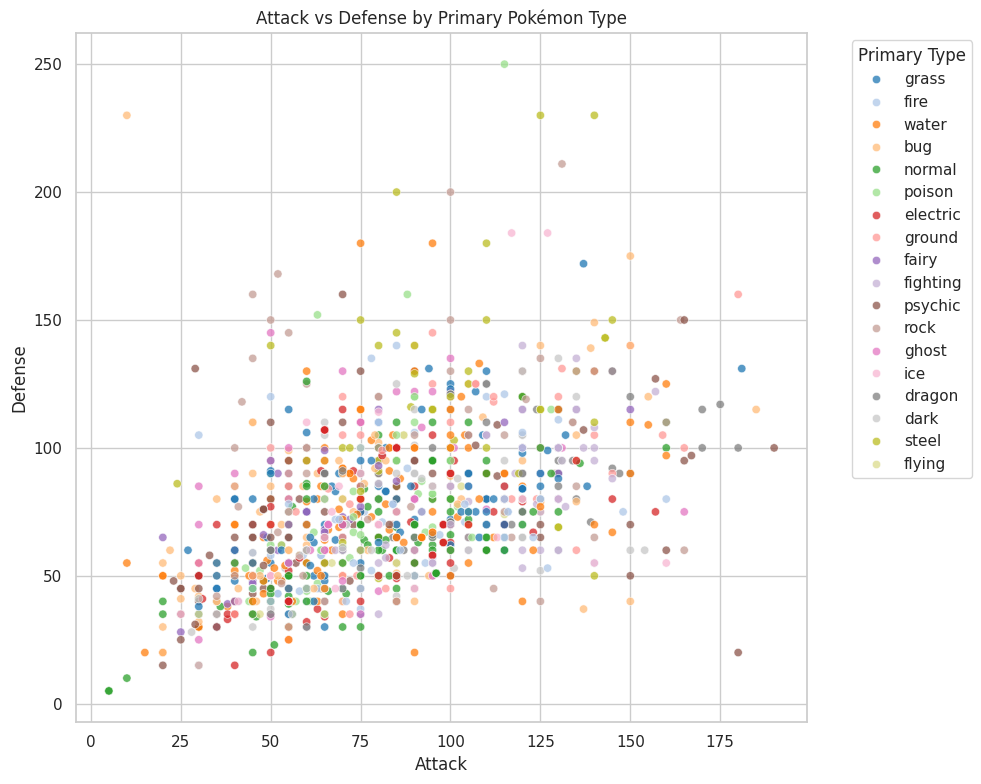

In [478]:
df = pd.read_csv('/content/G2.csv')
# Clean column names
df.columns = df.columns.str.strip()

sns.set_theme(style="whitegrid")
# 1. Attack vs Defense
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    hue="type_1",
    alpha=0.75,
    palette="tab20"
)

plt.title("Attack vs Defense by Primary Pokémon Type")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.legend(
    title="Primary Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

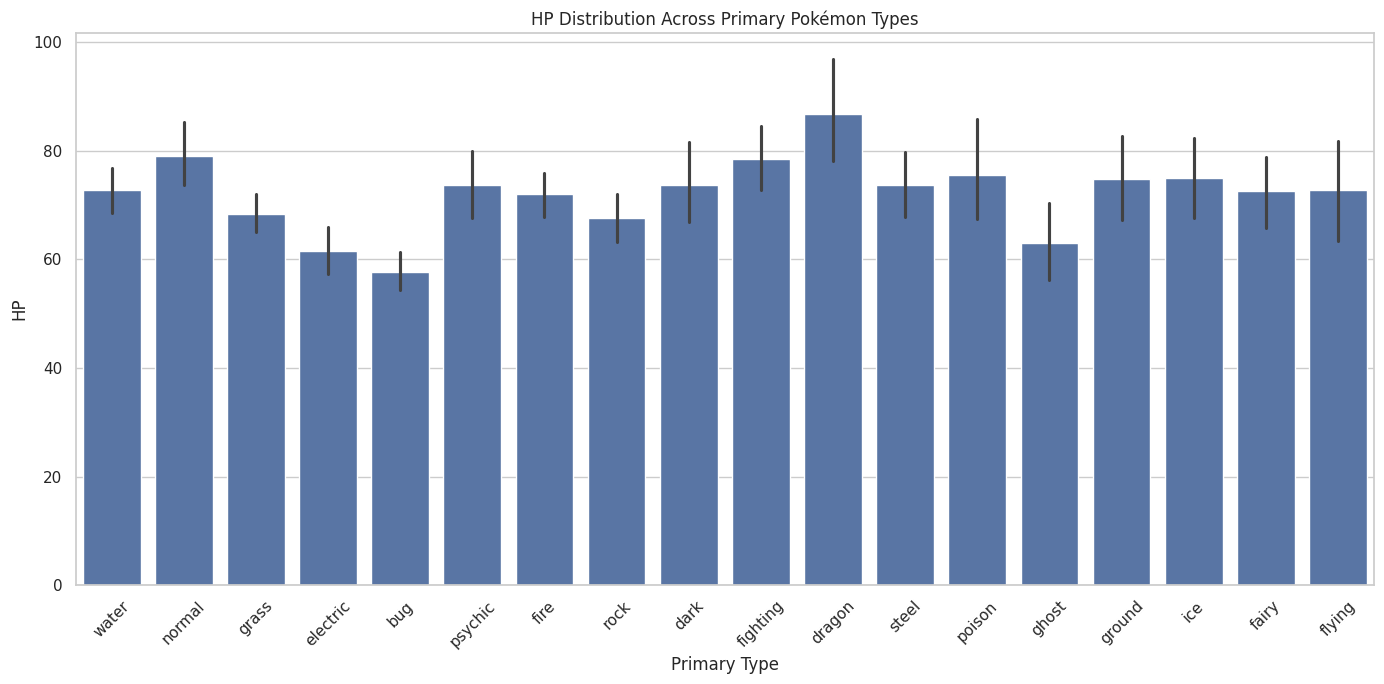

In [479]:
# 2. HP distribution across Pokémon types
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="type_1",
    y="hp",
    order=data["type_1"].value_counts().index
)

plt.title("HP Distribution Across Primary Pokémon Types")
plt.xlabel("Primary Type")
plt.ylabel("HP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


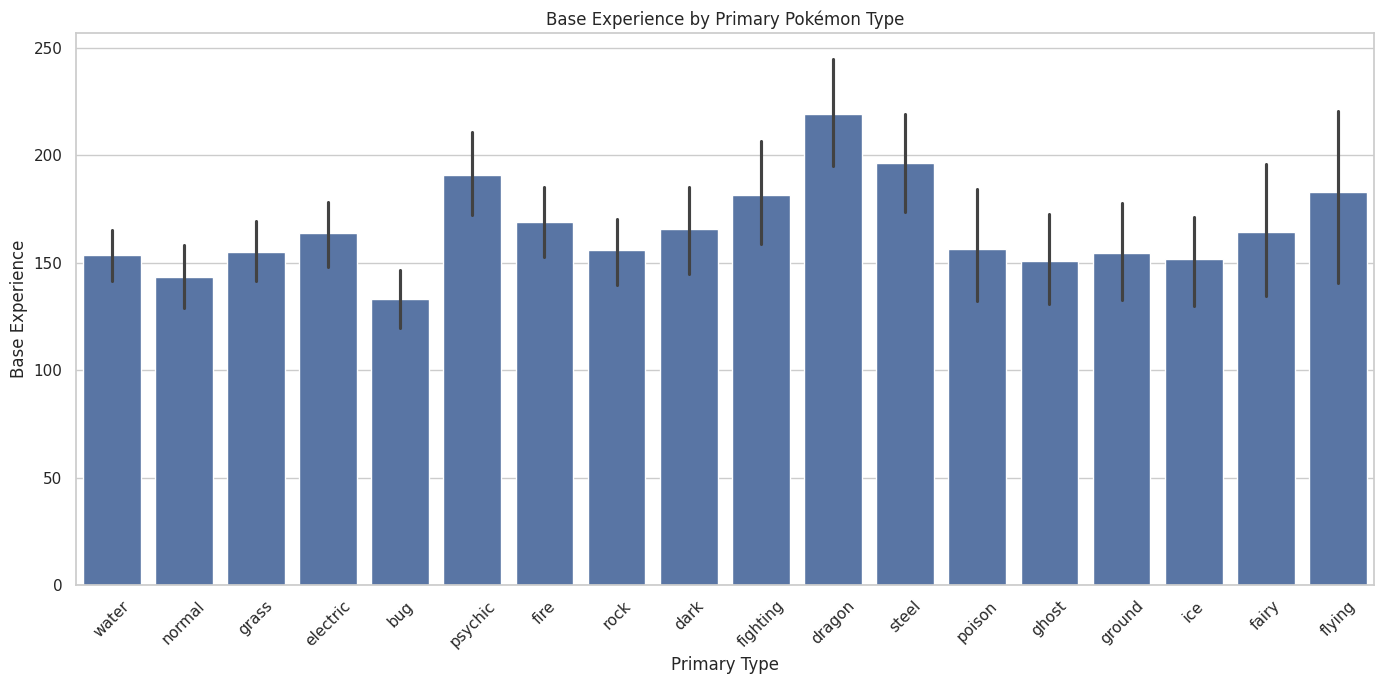

In [480]:
# 3. Base experience by Pokémon type
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="type_1",
    y="base_experience",
    order=data["type_1"].value_counts().index
)

plt.title("Base Experience by Primary Pokémon Type")
plt.xlabel("Primary Type")
plt.ylabel("Base Experience")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

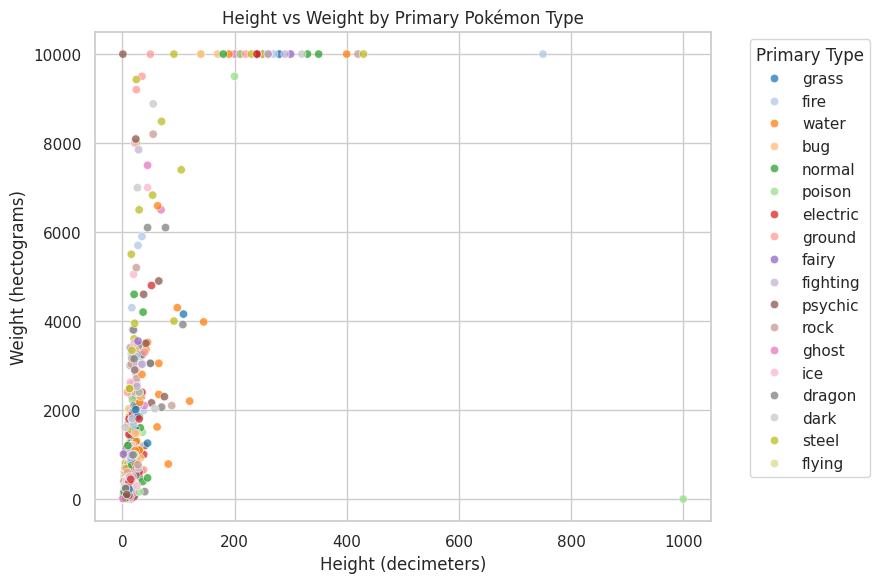

In [481]:
# 4. Height vs weight
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="height_dm",
    y="weight_hg",
    hue="type_1",
    alpha=0.75,
    palette="tab20"
)

plt.title("Height vs Weight by Primary Pokémon Type")
plt.xlabel("Height (decimeters)")
plt.ylabel("Weight (hectograms)")
plt.legend(
    title="Primary Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

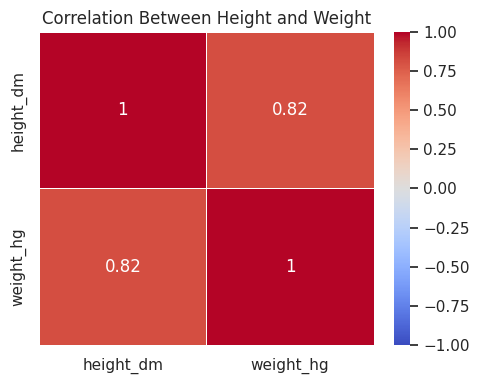

In [482]:
height_weight_correlation = data[["height_dm", "weight_hg"]].corr()
plt.figure(figsize=(5, 4))

sns.heatmap(
    height_weight_correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Between Height and Weight")
plt.tight_layout()
plt.show()


In [483]:
data.nunique()

,0
height_dm,34
weight_hg,458
base_experience,200
type_1,18
hp,92
attack,125
defense,111
type_2_bug,2
type_2_dark,2
type_2_dragon,2


1. Psychic type pokemon has most attack.

2. Yes there is a correlation between height and weight with a correlation coefficient of 0.67.

3. Weight appears most useful.

#Machine Learning Model

In [486]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append((name, accuracy_score(y_test, preds), f1_score(y_test, preds, average='macro')))
    fitted_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Macro F1']).sort_values('Macro F1', ascending=False)
print(results_df.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              Model  Accuracy  Macro F1
      Random Forest  0.273063  0.245326
  Gradient Boosting  0.261993  0.226450
      Decision Tree  0.188192  0.175495
Logistic Regression  0.121771  0.114384


In [487]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
print(f'\n The Most Influential Fr {best_name}')
print(classification_report(y_test, best_model.predict(X_test)))
#3. Rock is the most influential Feature


Best model: Random Forest
              precision    recall  f1-score   support

         bug       0.31      0.43      0.36        21
        dark       0.43      0.19      0.26        16
      dragon       0.36      0.33      0.35        12
    electric       0.20      0.25      0.22        12
       fairy       0.00      0.00      0.00         8
    fighting       0.35      0.39      0.37        18
        fire       0.21      0.14      0.17        22
      flying       0.00      0.00      0.00         1
       ghost       0.38      0.38      0.38         8
       grass       0.23      0.25      0.24        24
      ground       0.22      0.17      0.19        12
         ice       0.33      0.08      0.13        12
      normal       0.24      0.55      0.34        22
      poison       0.33      0.10      0.15        10
     psychic       0.38      0.28      0.32        18
        rock       0.47      0.50      0.48        14
       steel       0.43      0.23      0.30        13


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


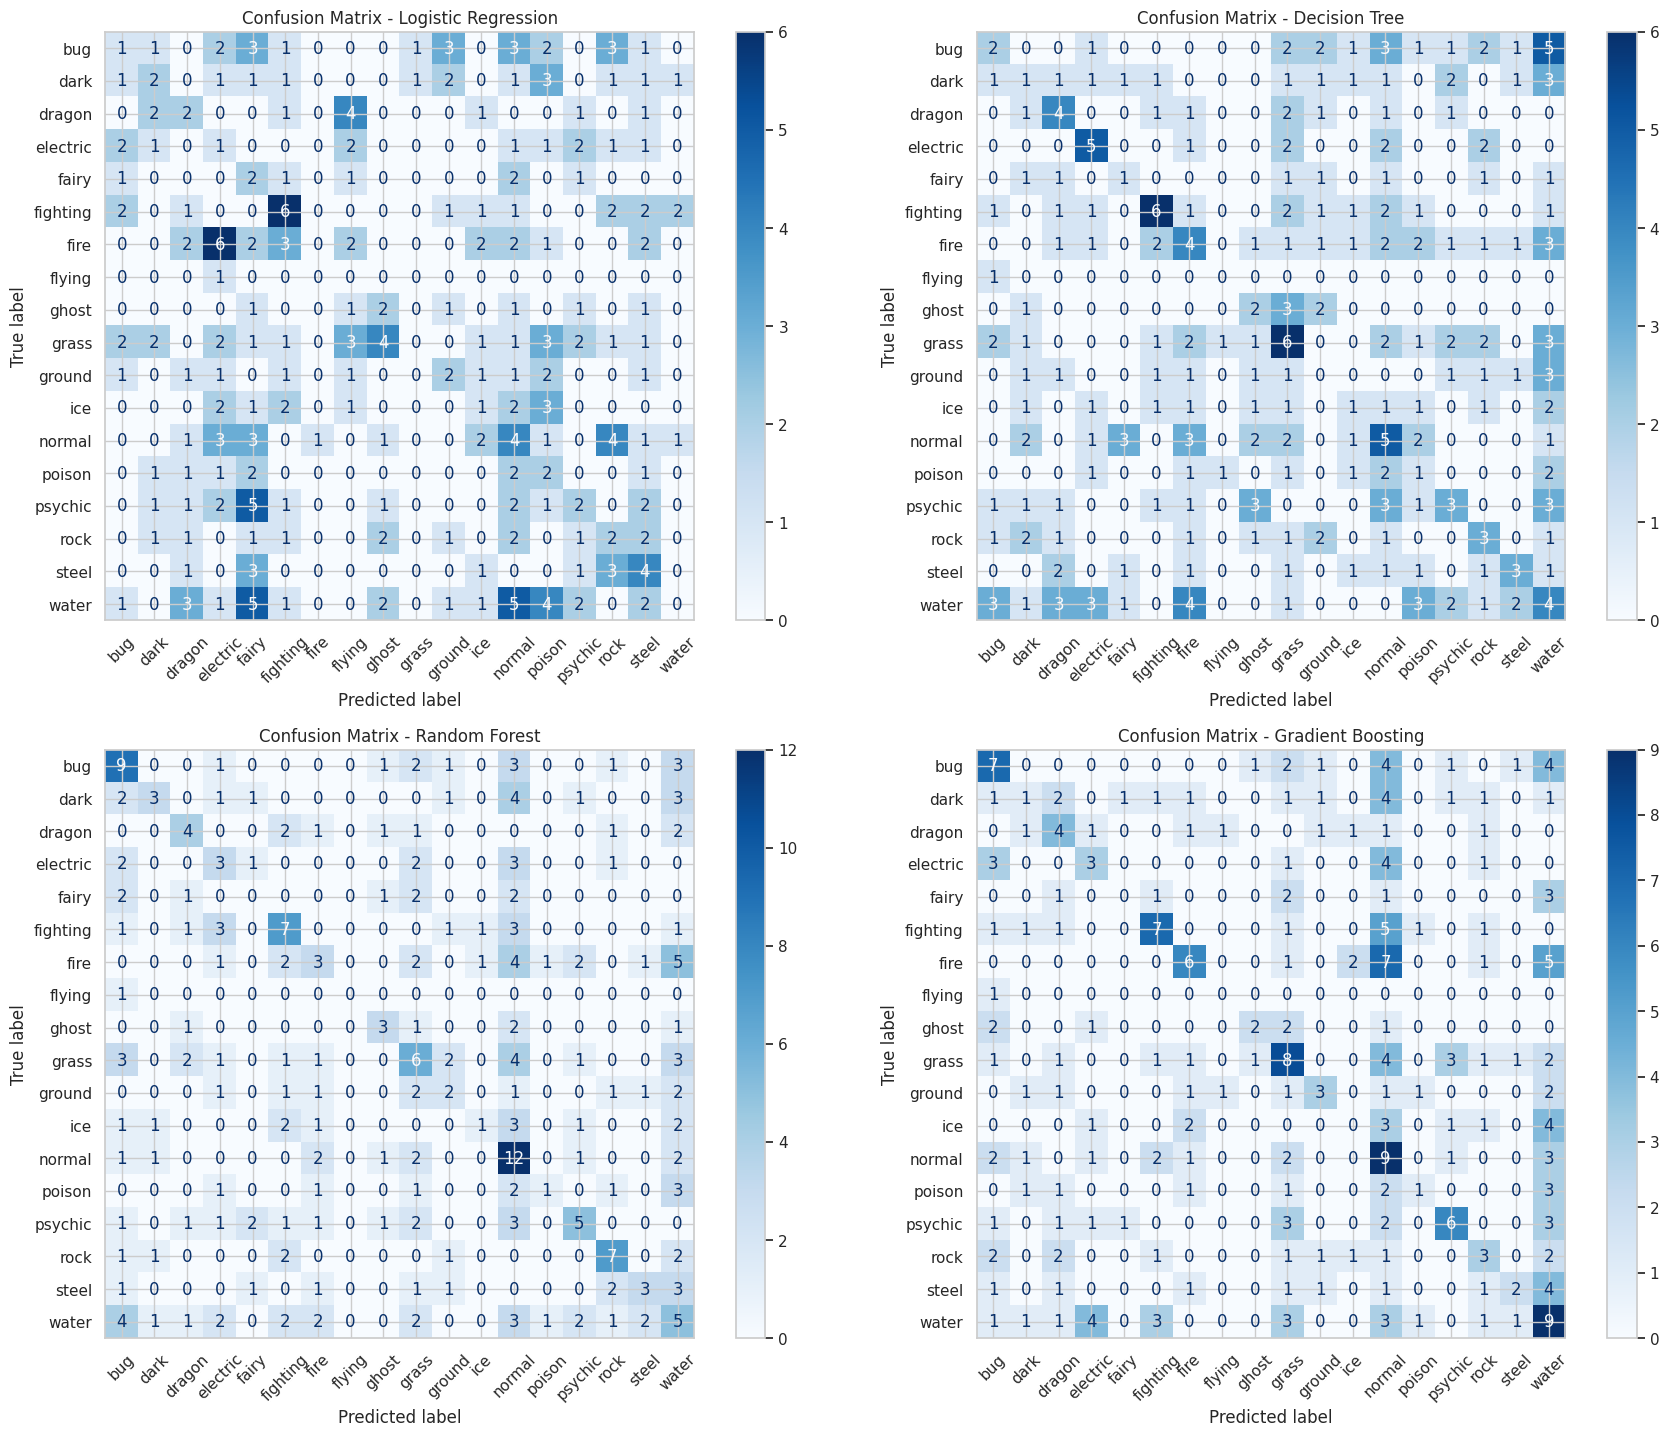

In [490]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Use the same class order for every classifier
labels = sorted(y.unique())

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(18, 28)
)

axes = axes.ravel()

for index, (model_name, model) in enumerate(fitted_models.items()):
    # Generate predictions
    y_pred = model.predict(X_test)

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        values_format="d",
        xticks_rotation=45,
        ax=axes[index]
    )

    axes[index].set_title(f"Confusion Matrix - {model_name}")

# Hide any unused subplot
for index in range(len(fitted_models), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.show()

In [493]:
from sklearn.metrics import accuracy_score

y_pred = fitted_models["Random Forest"].predict(X_test)

misclassified_count = (y_test != y_pred).sum()
total_count = len(y_test)

print("Misclassified samples:", misclassified_count)
print("Total samples:", total_count)
print("Error rate:", misclassified_count / total_count)

Misclassified samples: 197
Total samples: 271
Error rate: 0.7269372693726938


1. Random Forest achieved best performance with an  accuracy of  0.273063 and Macro F1 of  0.245326

2.Misclassified samples: 197
Total samples: 271
Error rate: 0.7269372693726938

3.  Water is the most difficult to predict.

In [495]:
import os
import pickle
from google.colab import files

# -------------------------------------------------------
# Create one bundle containing all trained objects
# -------------------------------------------------------

# Save the outlier clipping limits used during preprocessing
outlier_bounds = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outlier_bounds[col] = {
        "lower": Q1 - 1.5 * IQR,
        "upper": Q3 + 1.5 * IQR
    }

# Store all objects in one dictionary
model_bundle = {
    # Trained classifiers
    "fitted_models": fitted_models,

    # Best classifier information
    "best_model_name": best_name,
    "best_model": best_model,

    # Evaluation results
    "results_df": results_df,

    # Feature and target information
    "feature_columns": list(X.columns),
    "target_column": "type_1",
    "target_classes": sorted(y.unique()),

    # Preprocessing information
    "numeric_columns": numerical_cols,
    "categorical_columns": ["type_2"],
    "type_2_dummy_columns": [
        column for column in X.columns
        if column.startswith("type_2_")
    ],

    # Missing-value replacement values
    "type_2_missing_value": "none",
    "base_experience_median": float(
        data["base_experience"].median()
    ),

    # Outlier-handling limits
    "outlier_bounds": outlier_bounds,

    # Log-transformed column names
    "log_transformed_columns": [
        "height_dm_log",
        "weight_hg_log",
        "hp_log"
    ],

    # Save the label encoder only if it exists
    "label_encoder": globals().get("label_encoder", None),

    # Save a scaler only if one exists
    "scaler": globals().get("scaler", None),

    # Save an encoder only if one exists
    "onehot_encoder": globals().get("onehot_encoder", None),

    # Save a frequency encoder only if one exists
    "frequency_encoder": globals().get("frequency_encoder", None)
}

# Save the complete bundle as one PKL file
filename = "pokemon_type_prediction_bundle.pkl"

with open(filename, "wb") as file:
    pickle.dump(model_bundle, file)

print(f"Saved: {filename}")
print("Saved models:", list(fitted_models.keys()))
print("Best model:", best_name)

# Download the single PKL file in Google Colab
files.download(filename)

Saved: pokemon_type_prediction_bundle.pkl
Saved models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
Best model: Random Forest


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [496]:
import pickle

with open("pokemon_type_prediction_bundle.pkl", "rb") as file:
    model_bundle = pickle.load(file)

fitted_models = model_bundle["fitted_models"]
best_model = model_bundle["best_model"]
feature_columns = model_bundle["feature_columns"]

predictions = best_model.predict(X_test)